# 01: Audio Encoder Training (A1, A2, A3)

Train three MuQ domain adaptation strategies on Thunder Compute:
- **A1**: MuQ + LoRA multi-task (MuQLoRAModel)
- **A2**: Staged domain adaptation (MuQStagedModel) - Stage 1: self-supervised, Stage 2: supervised
- **A3**: Full unfreeze with gradual layer unfreezing (MuQFullUnfreezeModel)

All models use pre-extracted MuQ embeddings and PercePiano labels with 4-fold cross-validation.

---

## 1. Setup

In [2]:
import subprocess
import sys
import os
import torch
if torch.cuda.is_available():
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

In [3]:
import sys
from pathlib import Path

IS_CLOUD = Path('/workspace').exists()

if IS_CLOUD:
    get_ipython().system('git clone https://github.com/Jai-Dhiman/crescendAI.git /workspace/crescendai')
    get_ipython().run_line_magic('cd', '/workspace/crescendai/model')
    get_ipython().system('curl -LsSf https://astral.sh/uv/install.sh | sh')
    get_ipython().system(f'uv pip install -e . --python {sys.executable}')
    get_ipython().system('rclone sync gdrive:crescendai_data/model_improvement/data/percepiano_cache ./data/percepiano_cache --progress')
    get_ipython().system('rclone sync gdrive:crescendai_data/model_improvement/data/competition_cache ./data/competition_cache --progress')
    get_ipython().system('rclone sync gdrive:crescendai_data/model_improvement/data/maestro_cache ./data/maestro_cache --progress')
    get_ipython().system("rclone copy gdrive:crescendai_data/model_improvement/data/composite_labels ../data/composite_labels --progress 2>/dev/null || echo 'composite_labels: using local copy'")
else:
    # cd to model/ so all relative paths (data/, src/) work consistently
    _nb_dir = Path.cwd()
    _model_dir = _nb_dir
    while _model_dir.name != 'model' and _model_dir != _model_dir.parent:
        _model_dir = _model_dir.parent
    if _model_dir.name == 'model':
        get_ipython().run_line_magic('cd', str(_model_dir))

DATA_DIR = Path('data')
CHECKPOINT_DIR = Path('data/checkpoints/model_improvement')

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
print(f'DATA_DIR: {DATA_DIR.resolve()}')
print(f'CHECKPOINT_DIR: {CHECKPOINT_DIR.resolve()}')
print(f'Running on: {"cloud" if IS_CLOUD else "local"}')

/Users/jdhiman/Documents/crescendai/model
DATA_DIR: /Users/jdhiman/Documents/crescendai/model/data
CHECKPOINT_DIR: /Users/jdhiman/Documents/crescendai/model/data/checkpoints/model_improvement
Running on: local


In [4]:
import json
import numpy as np
import torch
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from torch.utils.data import DataLoader
from functools import partial

sys.path.insert(0, 'src')

from model_improvement.audio_encoders import MuQLoRAModel, MuQStagedModel, MuQFullUnfreezeModel
from model_improvement.training import train_model, find_checkpoint, detect_accelerator_config, upload_checkpoint
from model_improvement.data import (
    PairedPerformanceDataset, AugmentedEmbeddingDataset, AudioSegmentDataset,
    MaestroContrastiveDataset, stage1_collate_fn,
    audio_pair_collate_fn, multi_task_collate_fn,
)
from model_improvement.augmentation import AudioAugmentor
from model_improvement.taxonomy import load_composite_labels, NUM_DIMS, DIMENSIONS
from model_improvement.evaluation import (
    evaluate_model, aggregate_folds, run_robustness_check,
    select_winner, ROBUSTNESS_VETO_THRESHOLD,
)
from model_improvement.metrics import format_comparison_table
import matplotlib.pyplot as plt

## 2. Load Data

In [5]:
cache_dir = DATA_DIR / 'percepiano_cache'

# Load 6-dim composite labels (teacher-grounded taxonomy)
composite_path = DATA_DIR / 'composite_labels' / 'composite_labels.json'
labels_raw = load_composite_labels(composite_path)
labels = {k: v.tolist() for k, v in labels_raw.items()}
print(f'Loaded {len(labels)} composite labels ({NUM_DIMS} dims: {DIMENSIONS})')

emb_path = cache_dir / 'muq_embeddings.pt'
if emb_path.exists():
    embeddings = torch.load(emb_path, map_location='cpu', weights_only=True)
    print(f'Loaded {len(embeddings)} pre-computed embeddings')
else:
    print('muq_embeddings.pt not found -- extracting from audio (one-time, ~20 min on A100)...')
    import gc
    from audio_experiments.extractors.muq import MuQExtractor

    audio_dir = DATA_DIR / 'percepiano_audio'
    if not audio_dir.exists() or not any(audio_dir.glob('*.wav')):
        raise FileNotFoundError(
            f'No wav files at {audio_dir}. Sync percepiano_audio/ from GDrive first.'
        )

    extractor = MuQExtractor(cache_dir=cache_dir / '_muq_file_cache')
    embeddings = {}
    missing = []
    keys = sorted(labels.keys())
    for i, key in enumerate(keys, 1):
        wav = audio_dir / f'{key}.wav'
        if not wav.exists():
            missing.append(key)
            continue
        embeddings[key] = extractor.extract_from_file(wav)
        if i % 100 == 0:
            print(f'  [{i}/{len(keys)}] extracted')

    del extractor
    gc.collect()
    torch.cuda.empty_cache()

    if missing:
        print(f'WARNING: {len(missing)} wav files not found')

    torch.save(embeddings, emb_path)
    print(f'Saved {len(embeddings)} embeddings to {emb_path}')

    # Cache to GDrive so future runs skip extraction
    subprocess.run([
        'rclone', 'copy', str(emb_path),
        'gdrive:crescendai_data/model_improvement/data/percepiano_cache/',
        '--progress',
    ], check=True)

print(f'Labels: {len(labels)}, Embeddings: {len(embeddings)}')
sample_key = next(iter(embeddings))
print(f'Sample embedding shape: {embeddings[sample_key].shape}')

Loaded 1202 composite labels (6 dims: ['dynamics', 'timing', 'pedaling', 'articulation', 'phrasing', 'interpretation'])
Loaded 1201 pre-computed embeddings
Labels: 1202, Embeddings: 1201
Sample embedding shape: torch.Size([426, 1024])


In [6]:
with open(cache_dir / 'folds.json') as f:
    folds = json.load(f)

print(f'Number of folds: {len(folds)}')
for i, fold in enumerate(folds):
    print(f'  Fold {i}: {len(fold["train"])} train, {len(fold["val"])} val')

Number of folds: 4
  Fold 0: 758 train, 263 val
  Fold 1: 787 train, 234 val
  Fold 2: 766 train, 255 val
  Fold 3: 752 train, 269 val


In [7]:
# Build piece mapping from labels metadata
# Each label key encodes piece info; group recordings by piece
with open(cache_dir / 'piece_mapping.json') as f:
    piece_to_keys = json.load(f)

print(f'Pieces with multiple performances: {len(piece_to_keys)}')
total_keys = sum(len(v) for v in piece_to_keys.values())
print(f'Total recordings in piece mapping: {total_keys}')

Pieces with multiple performances: 61
Total recordings in piece mapping: 964


## 3. Training Utilities

In [8]:
# On macOS (spawn), collate_fn closures pickle the full embeddings dict
# (~2 GB) into each worker -- use 0 workers locally to avoid OOM.
_NUM_WORKERS = 4 if torch.cuda.is_available() else 0
_PIN_MEMORY = torch.cuda.is_available()

LOW_MEMORY = not torch.cuda.is_available()
_BATCH_SIZE = 4 if LOW_MEMORY else 16
_ACCUM_BATCHES = 4 if LOW_MEMORY else 1

print(f'[memory config] LOW_MEMORY={LOW_MEMORY}  batch_size={_BATCH_SIZE}  accum={_ACCUM_BATCHES}  workers={_NUM_WORKERS}')


def build_dataloaders(fold, labels, piece_to_keys, embeddings, cache_dir, batch_size=_BATCH_SIZE, include_augmented=False):
    """Build train/val DataLoaders for a given fold."""
    collate_fn = partial(audio_pair_collate_fn, embeddings=embeddings)

    if include_augmented:
        # Self-supervised: per-segment dataset with clean + augmented embeddings
        train_ds = AudioSegmentDataset(
            embeddings=embeddings,
            piece_to_keys=piece_to_keys,
            keys=fold['train'],
        )
        val_ds = AudioSegmentDataset(
            embeddings=embeddings,
            piece_to_keys=piece_to_keys,
            keys=fold['val'],
        )
        collate_fn = multi_task_collate_fn
    else:
        # Supervised: paired dataset with audio collate
        train_ds = PairedPerformanceDataset(
            cache_dir=cache_dir,
            labels=labels,
            piece_to_keys=piece_to_keys,
            keys=fold['train'],
        )
        val_ds = PairedPerformanceDataset(
            cache_dir=cache_dir,
            labels=labels,
            piece_to_keys=piece_to_keys,
            keys=fold['val'],
        )

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        collate_fn=collate_fn, num_workers=_NUM_WORKERS, pin_memory=_PIN_MEMORY,
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        collate_fn=collate_fn, num_workers=_NUM_WORKERS, pin_memory=_PIN_MEMORY,
    )
    return train_loader, val_loader

[memory config] LOW_MEMORY=True  batch_size=4  accum=4  workers=0


## 4. Train A1: MuQ + LoRA

In [9]:
A1_CONFIG = {
    'input_dim': 1024,
    'hidden_dim': 512,
    'num_labels': NUM_DIMS,
    'learning_rate': 3e-5,
    'weight_decay': 1e-5,
    'temperature': 0.07,
    'lambda_contrastive': 0.3,
    'lambda_regression': 0.5,
    'lambda_invariance': 0.1,
    'warmup_epochs': 5,
    'max_epochs': 200,
    'use_pretrained_muq': False,  # Using pre-extracted embeddings
}

print('Training A1: MuQ + LoRA Multi-Task')
print('=' * 50)

a1_trainers = []
a1_models = []
for fold_idx, fold in enumerate(folds):
    print(f'\nFold {fold_idx}/{len(folds)-1}')

    existing = find_checkpoint(CHECKPOINT_DIR, 'A1', fold_idx)
    if existing:
        print(f'  Loading existing checkpoint: {existing.name}')
        model = MuQLoRAModel.load_from_checkpoint(existing, **A1_CONFIG)
        a1_models.append(model)
        a1_trainers.append(None)
        continue

    model = MuQLoRAModel(**A1_CONFIG)
    train_loader, val_loader = build_dataloaders(
        fold, labels, piece_to_keys, embeddings, cache_dir,
        batch_size=_BATCH_SIZE,
    )

    trainer = train_model(
        model, train_loader, val_loader, 'A1', fold_idx,
        checkpoint_dir=CHECKPOINT_DIR,
        max_epochs=A1_CONFIG['max_epochs'],
        patience=10,
        accumulate_grad_batches=_ACCUM_BATCHES,
    )
    a1_trainers.append(trainer)
    a1_models.append(trainer.lightning_module)

    best_val = trainer.callback_metrics.get('val_loss', float('inf'))
    best_acc = trainer.callback_metrics.get('val_pairwise_acc', 0.0)
    print(f'  Best val_loss={best_val:.4f}, val_pairwise_acc={best_acc:.4f}')

Training A1: MuQ + LoRA Multi-Task

Fold 0/3
  Loading existing checkpoint: epoch=8-val_loss=0.4879.ckpt

Fold 1/3
  Loading existing checkpoint: epoch=5-val_loss=0.5473.ckpt

Fold 2/3
  Loading existing checkpoint: epoch=6-val_loss=0.4325.ckpt

Fold 3/3
  Loading existing checkpoint: epoch=5-val_loss=0.5450.ckpt


## 5. Train A2: Staged Domain Adaptation

### Note: A2 pretraining stays on PercePiano only (for now)

Unlike the symbolic encoders (02_symbolic_training.ipynb) which now pretrain on a
~14K MIDI corpus (MAESTRO + ATEPP + ASAP + PercePiano), the audio encoders here
continue to pretrain only on PercePiano data. The rationale:

1. **MuQ already has strong audio priors.** MuQ is pretrained on 160K hours of
   diverse music, so the marginal value of adding more piano audio is lower than
   for symbolic encoders which start from scratch.
2. **Audio data is expensive.** MAESTRO audio is ~200GB; downloading and processing
   it on Thunder Compute is costly relative to the expected benefit.
3. **Stage 1 is self-supervised on embeddings.** The cross-performer contrastive and
   augmentation invariance objectives work well with PercePiano's 1,202 segments.

**Decision (2026-02-24):** Proceeding with PercePiano-only Stage 1 for initial run.
MAESTRO MuQ embeddings (24K segments, 204 pieces) are available in GDrive. See
Section 5b below for the ablation cell if results warrant it.

In [10]:
A2_CONFIG = {
    'input_dim': 1024,
    'hidden_dim': 512,
    'num_labels': NUM_DIMS,
    'learning_rate': 3e-5,
    'weight_decay': 1e-5,
    'temperature': 0.07,
    'lambda_contrastive': 0.3,
    'lambda_regression': 0.5,
    'lambda_invariance': 0.5,
    'warmup_epochs': 5,
    'max_epochs': 200,
    'use_pretrained_muq': False,
}

STAGE1_EPOCHS = 50
STAGE2_EPOCHS = 150

print('Training A2: Staged Domain Adaptation')
print('=' * 50)

a2_trainers = []
a2_models = []
for fold_idx, fold in enumerate(folds):
    print(f'\nFold {fold_idx}/{len(folds)-1}')

    # Check if Stage 2 (final) is already done
    existing_s2 = find_checkpoint(CHECKPOINT_DIR, 'A2', fold_idx)
    if existing_s2:
        print(f'  Loading existing A2 checkpoint: {existing_s2.name}')
        model = MuQStagedModel.load_from_checkpoint(existing_s2, **A2_CONFIG, stage='supervised')
        a2_models.append(model)
        a2_trainers.append(None)
        continue

    # --- Stage 1: Self-supervised ---
    existing_s1 = find_checkpoint(CHECKPOINT_DIR, 'A2_stage1', fold_idx)
    if existing_s1:
        print(f'  Stage 1: loading existing checkpoint: {existing_s1.name}')
        model = MuQStagedModel.load_from_checkpoint(existing_s1, **A2_CONFIG, stage='self_supervised')
    else:
        print('  Stage 1: Self-supervised (contrastive + invariance)')
        model = MuQStagedModel(**A2_CONFIG, stage='self_supervised')
        train_loader_ss, val_loader_ss = build_dataloaders(
            fold, labels, piece_to_keys, embeddings, cache_dir,
            batch_size=_BATCH_SIZE, include_augmented=True,
        )
        train_model(
            model, train_loader_ss, val_loader_ss,
            'A2_stage1', fold_idx,
            checkpoint_dir=CHECKPOINT_DIR,
            max_epochs=STAGE1_EPOCHS,
            patience=10,
            accumulate_grad_batches=_ACCUM_BATCHES,
        )

    # --- Stage 2: Supervised ---
    print('  Stage 2: Supervised (ranking + regression)')
    model.switch_to_supervised()
    train_loader, val_loader = build_dataloaders(
        fold, labels, piece_to_keys, embeddings, cache_dir,
        batch_size=_BATCH_SIZE,
    )
    trainer_s2 = train_model(
        model, train_loader, val_loader,
        'A2', fold_idx,
        checkpoint_dir=CHECKPOINT_DIR,
        max_epochs=STAGE2_EPOCHS,
        patience=10,
        accumulate_grad_batches=_ACCUM_BATCHES,
    )
    a2_trainers.append(trainer_s2)
    a2_models.append(trainer_s2.lightning_module)

    best_val = trainer_s2.callback_metrics.get('val_loss', float('inf'))
    best_acc = trainer_s2.callback_metrics.get('val_pairwise_acc', 0.0)
    print(f'  Best val_loss={best_val:.4f}, val_pairwise_acc={best_acc:.4f}')

Training A2: Staged Domain Adaptation

Fold 0/3
  Loading existing A2 checkpoint: epoch=6-val_loss=0.4693.ckpt

Fold 1/3
  Loading existing A2 checkpoint: epoch=4-val_loss=0.5396.ckpt

Fold 2/3
  Loading existing A2 checkpoint: epoch=5-val_loss=0.4822.ckpt

Fold 3/3
  Loading existing A2 checkpoint: epoch=3-val_loss=0.5327.ckpt


### 5b. Ablation: A2 Stage 1 with MAESTRO Data

Optional. Re-runs A2 Stage 1 using PercePiano + MAESTRO cross-performer
contrastive data (~25x more segments). Set `RUN_MAESTRO_ABLATION = True`
to enable after reviewing baseline A2 results.

MAESTRO adds 24,321 segments across 204 pieces (vs PercePiano's 964
segments / 61 pieces). All MAESTRO pieces have >=2 performer recordings,
providing richer cross-performer contrastive signal for Stage 1.

In [11]:
RUN_MAESTRO_ABLATION = True

if RUN_MAESTRO_ABLATION:
    import gc
    from torch.utils.data import ConcatDataset

    # -- Free prior models to reclaim memory before MAESTRO training --
    # (Evaluation cells reload from checkpoints; no data is lost.)
    a1_models, a1_trainers = [], []
    a2_models, a2_trainers = [], []
    gc.collect()
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        torch.mps.empty_cache()

    # -- Sync MAESTRO MuQ embeddings + contrastive mapping from GDrive (skip if local) --
    maestro_emb_dir = DATA_DIR / 'maestro_cache' / 'muq_embeddings'
    maestro_mapping_path = DATA_DIR / 'maestro_cache' / 'contrastive_mapping.json'

    if not any(maestro_emb_dir.glob('*.pt')):
        maestro_emb_dir.mkdir(parents=True, exist_ok=True)
        subprocess.run([
            'rclone', 'sync',
            'gdrive:crescendai_data/model_improvement/data/maestro_cache/muq_embeddings',
            str(maestro_emb_dir), '--progress',
        ], check=True)
    else:
        print(f'MAESTRO embeddings already cached ({len(list(maestro_emb_dir.glob("*.pt")))} files)')

    if not maestro_mapping_path.exists():
        subprocess.run([
            'rclone', 'copy',
            'gdrive:crescendai_data/model_improvement/data/maestro_cache/contrastive_mapping.json',
            str(maestro_mapping_path.parent), '--progress',
        ], check=True)
    else:
        print('MAESTRO contrastive mapping already cached')

    with open(maestro_mapping_path) as f:
        maestro_contrastive = json.load(f)

    # -- Build MAESTRO dataset (imported from data.py, picklable for multiprocessing) --
    piece_id_offset = len(piece_to_keys)
    maestro_ds = MaestroContrastiveDataset(
        maestro_emb_dir, maestro_contrastive, piece_id_offset=piece_id_offset,
        max_frames=500,
    )

    # On macOS (spawn), ConcatDataset with in-memory AudioSegmentDataset
    # gets pickled into each worker -- OOM with 2+ workers on 32GB.
    # Use num_workers=0 for Stage 1 combined loader.
    _s1_workers = _NUM_WORKERS if torch.cuda.is_available() else 0

    print('Training A2 (MAESTRO ablation): Staged Domain Adaptation')
    print('=' * 60)

    a2_maestro_trainers = []
    a2_maestro_models = []
    for fold_idx, fold in enumerate(folds):
        print(f'\nFold {fold_idx}/{len(folds)-1}')

        # Check if Stage 2 (final) is already done
        existing_s2 = find_checkpoint(CHECKPOINT_DIR, 'A2_maestro', fold_idx)
        if existing_s2:
            print(f'  Loading existing A2_maestro checkpoint: {existing_s2.name}')
            model = MuQStagedModel.load_from_checkpoint(existing_s2, **A2_CONFIG, stage='supervised')
            a2_maestro_models.append(model)
            a2_maestro_trainers.append(None)
            continue

        # Stage 1: check for existing checkpoint
        existing_s1 = find_checkpoint(CHECKPOINT_DIR, 'A2_maestro_stage1', fold_idx)
        if existing_s1:
            print(f'  Stage 1: loading existing checkpoint: {existing_s1.name}')
            model = MuQStagedModel.load_from_checkpoint(existing_s1, **A2_CONFIG, stage='self_supervised')
        else:
            print('  Stage 1: Self-supervised (PercePiano + MAESTRO)')
            model = MuQStagedModel(**A2_CONFIG, stage='self_supervised')

            pp_train_ds = AudioSegmentDataset(
                embeddings=embeddings,
                piece_to_keys=piece_to_keys,
                keys=fold['train'],
                max_frames=500,
            )
            combined_ds = ConcatDataset([pp_train_ds, maestro_ds])

            pp_val_ds = AudioSegmentDataset(
                embeddings=embeddings,
                piece_to_keys=piece_to_keys,
                keys=fold['val'],
                max_frames=500,
            )

            train_loader_s1 = DataLoader(
                combined_ds, batch_size=_BATCH_SIZE, shuffle=True,
                collate_fn=stage1_collate_fn, num_workers=_s1_workers,
            )
            val_loader_s1 = DataLoader(
                pp_val_ds, batch_size=_BATCH_SIZE, shuffle=False,
                collate_fn=stage1_collate_fn, num_workers=_s1_workers,
            )

            train_model(
                model, train_loader_s1, val_loader_s1,
                'A2_maestro_stage1', fold_idx,
                checkpoint_dir=CHECKPOINT_DIR,
                max_epochs=STAGE1_EPOCHS,
                accumulate_grad_batches=_ACCUM_BATCHES,
            )

        # Stage 2: Supervised on PercePiano only (unchanged from baseline A2)
        print('  Stage 2: Supervised (PercePiano only)')
        model.switch_to_supervised()

        train_loader, val_loader = build_dataloaders(
            fold, labels, piece_to_keys, embeddings, cache_dir,
            batch_size=_BATCH_SIZE,
        )

        trainer_s2 = train_model(
            model, train_loader, val_loader,
            'A2_maestro', fold_idx,
            checkpoint_dir=CHECKPOINT_DIR,
            max_epochs=STAGE2_EPOCHS,
            accumulate_grad_batches=_ACCUM_BATCHES,
        )
        a2_maestro_trainers.append(trainer_s2)
        a2_maestro_models.append(trainer_s2.lightning_module)

        best_val = trainer_s2.callback_metrics.get('val_loss', float('inf'))
        best_acc = trainer_s2.callback_metrics.get('val_pairwise_acc', 0.0)
        print(f'  Best val_loss={best_val:.4f}, val_pairwise_acc={best_acc:.4f}')

    print(f'\nA2 MAESTRO ablation complete. Stored in a2_maestro_trainers.')
    print('Compare with baseline A2 in sections 9-12.')
else:
    a2_maestro_trainers = []
    a2_maestro_models = []
    print('MAESTRO ablation skipped (RUN_MAESTRO_ABLATION = False).')
    print('Set RUN_MAESTRO_ABLATION = True above to enable after reviewing baseline A2 results.')

MAESTRO embeddings already cached (24321 files)
MAESTRO contrastive mapping already cached
MaestroContrastiveDataset: 12181 segments, 204 pieces (offset=61)
Training A2 (MAESTRO ablation): Staged Domain Adaptation

Fold 0/3
  Loading existing A2_maestro checkpoint: epoch=7-val_loss=0.4545.ckpt

Fold 1/3
  Loading existing A2_maestro checkpoint: epoch=4-val_loss=0.5688.ckpt

Fold 2/3
  Loading existing A2_maestro checkpoint: epoch=4-val_loss=0.4573.ckpt

Fold 3/3
  Loading existing A2_maestro checkpoint: epoch=3-val_loss=0.5446.ckpt

A2 MAESTRO ablation complete. Stored in a2_maestro_trainers.
Compare with baseline A2 in sections 9-12.


## 6. Train A3: Full Unfreeze

In [12]:
# -- Free prior models to reclaim memory before A3 training --
import gc
a2_maestro_models, a2_maestro_trainers = [], []
gc.collect()
if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    torch.mps.empty_cache()

A3_CONFIG = {
    'input_dim': 1024,
    'hidden_dim': 512,
    'num_labels': NUM_DIMS,
    'learning_rate': 3e-5,
    'weight_decay': 1e-5,
    'temperature': 0.07,
    'lambda_contrastive': 0.3,
    'lambda_regression': 0.5,
    'warmup_epochs': 5,
    'max_epochs': 200,
    'use_pretrained_muq': False,
    'unfreeze_schedule': {0: [12], 10: [11], 20: [10], 30: [9]},
    'lr_decay_factor': 0.8,
    'use_gradient_checkpointing': LOW_MEMORY,
}

print('Training A3: Full Unfreeze with Gradual Layer Unfreezing')
print('=' * 50)

a3_trainers = []
a3_models = []
for fold_idx, fold in enumerate(folds):
    print(f'\nFold {fold_idx}/{len(folds)-1}')

    existing = find_checkpoint(CHECKPOINT_DIR, 'A3', fold_idx)
    if existing:
        print(f'  Loading existing checkpoint: {existing.name}')
        model = MuQFullUnfreezeModel.load_from_checkpoint(existing, **A3_CONFIG)
        a3_models.append(model)
        a3_trainers.append(None)
        continue

    model = MuQFullUnfreezeModel(**A3_CONFIG)
    train_loader, val_loader = build_dataloaders(
        fold, labels, piece_to_keys, embeddings, cache_dir,
        batch_size=_BATCH_SIZE,
    )

    trainer = train_model(
        model, train_loader, val_loader, 'A3', fold_idx,
        checkpoint_dir=CHECKPOINT_DIR,
        max_epochs=A3_CONFIG['max_epochs'],
        patience=10,
        accumulate_grad_batches=_ACCUM_BATCHES,
    )
    a3_trainers.append(trainer)
    a3_models.append(trainer.lightning_module)

    best_val = trainer.callback_metrics.get('val_loss', float('inf'))
    best_acc = trainer.callback_metrics.get('val_pairwise_acc', 0.0)
    print(f'  Best val_loss={best_val:.4f}, val_pairwise_acc={best_acc:.4f}')

Training A3: Full Unfreeze with Gradual Layer Unfreezing

Fold 0/3
  Loading existing checkpoint: epoch=4-val_loss=0.6443.ckpt

Fold 1/3
  Loading existing checkpoint: epoch=5-val_loss=0.5358.ckpt

Fold 2/3
  Loading existing checkpoint: epoch=6-val_loss=0.4507.ckpt

Fold 3/3
  Loading existing checkpoint: epoch=5-val_loss=0.5160.ckpt


## 7. Training Summary

In [13]:
import re
import logging
logging.getLogger('model_improvement.evaluation').setLevel(logging.INFO)

_MODEL_REGISTRY = {
    'A1': (MuQLoRAModel, A1_CONFIG, {}),
    'A2': (MuQStagedModel, A2_CONFIG, {'stage': 'supervised'}),
    'A2_maestro': (MuQStagedModel, A2_CONFIG, {'stage': 'supervised'}),
    'A3': (MuQFullUnfreezeModel, A3_CONFIG, {}),
}

def _get_val_metrics(trainer, model, model_name, fold_idx, fold_data):
    """Extract val metrics from trainer or by evaluating the loaded model."""
    if trainer is not None:
        return (
            float(trainer.callback_metrics.get('val_loss', float('nan'))),
            float(trainer.callback_metrics.get('val_pairwise_acc', float('nan'))),
        )

    # Get val_loss from checkpoint filename
    ckpt = find_checkpoint(CHECKPOINT_DIR, model_name, fold_idx)
    val_loss = float('nan')
    if ckpt is not None:
        match = re.search(r'val_loss=(\d+\.\d+)', ckpt.name)
        if match:
            val_loss = float(match.group(1))

    # Resolve model: use in-memory (moved to CPU) or reload from checkpoint
    _model = model
    _needs_free = False
    if _model is None and ckpt is not None and model_name in _MODEL_REGISTRY:
        cls, config, extra_kw = _MODEL_REGISTRY[model_name]
        _model = cls.load_from_checkpoint(ckpt, map_location='cpu', **config, **extra_kw)
        _needs_free = True
    elif _model is not None:
        _model.cpu()

    # Compute pairwise accuracy
    val_acc = float('nan')
    if _model is not None and fold_data is not None:
        res = evaluate_model(
            _model, fold_data['val'], labels,
            get_input_fn=lambda key: (embeddings[key].unsqueeze(0), None),
            encode_fn=lambda m, inp, mask: m.encode(inp, mask),
            compare_fn=lambda m, z_a, z_b: m.compare(z_a, z_b),
            predict_fn=lambda m, inp, mask: (
                m.predict_scores(inp, mask) if hasattr(m, 'predict_scores')
                else m.regression_head(m.encode(inp, mask))
            ),
        )
        val_acc = float(res.get('pairwise', float('nan')))

    # Free reloaded model to save memory
    if _needs_free:
        del _model

    return val_loss, val_acc

print('Training Summary')
print('=' * 60)
print(f'{"Model":<16} {"Fold":<6} {"Val Loss":<12} {"Pairwise Acc":<14}')
print('-' * 60)

model_groups = [
    ('A1', a1_trainers, a1_models),
    ('A2', a2_trainers, a2_models),
    ('A3', a3_trainers, a3_models),
]
if a2_maestro_trainers:
    model_groups.append(('A2_maestro', a2_maestro_trainers, a2_maestro_models))

for name, trainers, models in model_groups:
    # Handle empty lists (models freed by earlier cells for memory)
    _trainers = trainers if trainers else [None] * len(folds)
    _models = models if models else [None] * len(folds)
    for fold_idx in range(len(folds)):
        trainer = _trainers[fold_idx] if fold_idx < len(_trainers) else None
        model = _models[fold_idx] if fold_idx < len(_models) else None
        val_loss, val_acc = _get_val_metrics(trainer, model, name, fold_idx, folds[fold_idx])
        print(f'{name:<16} {fold_idx:<6} {val_loss:<12.4f} {val_acc:<14.4f}')

print('\nCheckpoints saved to:', CHECKPOINT_DIR)
print('Checkpoints synced to Google Drive via rclone')

Training Summary
Model            Fold   Val Loss     Pairwise Acc  
------------------------------------------------------------
  encoding 263 keys...
  encode: 50/263
  encode: 100/263
  encode: 150/263
  encode: 200/263


evaluate_model encode: 'Schubert_D935_no.3_4bars_2_1' (suppressing further)


  encode: 250/263
  pairwise: 5000/34191 pairs (15%)
  pairwise: 10000/34191 pairs (29%)
  pairwise: 15000/34191 pairs (44%)
  pairwise: 20000/34191 pairs (58%)
  pairwise: 25000/34191 pairs (73%)
  pairwise: 30000/34191 pairs (88%)
  r2: 100/263 keys
  r2: 200/263 keys


evaluate_model r2: 'Schubert_D935_no.3_4bars_2_1' (suppressing further)


A1               0      0.4879       0.7766        
  encoding 234 keys...
  encode: 50/234
  encode: 100/234
  encode: 150/234
  encode: 200/234
  pairwise: 5000/27261 pairs (18%)
  pairwise: 10000/27261 pairs (37%)
  pairwise: 15000/27261 pairs (55%)
  pairwise: 20000/27261 pairs (73%)
  pairwise: 25000/27261 pairs (92%)
  r2: 100/234 keys
  r2: 200/234 keys
A1               1      0.5473       0.7034        
  encoding 255 keys...
  encode: 50/255
  encode: 100/255
  encode: 150/255
  encode: 200/255
  encode: 250/255
  pairwise: 5000/32385 pairs (15%)
  pairwise: 10000/32385 pairs (31%)
  pairwise: 15000/32385 pairs (46%)
  pairwise: 20000/32385 pairs (62%)
  pairwise: 25000/32385 pairs (77%)
  pairwise: 30000/32385 pairs (93%)
  r2: 100/255 keys
  r2: 200/255 keys
A1               2      0.4325       0.7660        
  encoding 269 keys...
  encode: 50/269
  encode: 100/269
  encode: 150/269
  encode: 200/269
  encode: 250/269
  pairwise: 5000/36046 pairs (14%)
  pairwise: 10000/360

...

A2               0      0.4693       0.7864        
  encoding 234 keys...
  encode: 50/234
  encode: 100/234
  encode: 150/234
  encode: 200/234
  pairwise: 5000/27261 pairs (18%)
  pairwise: 10000/27261 pairs (37%)
  pairwise: 15000/27261 pairs (55%)
  pairwise: 20000/27261 pairs (73%)
  pairwise: 25000/27261 pairs (92%)
  r2: 100/234 keys
  r2: 200/234 keys
A2               1      0.5396       0.6898        
  encoding 255 keys...
  encode: 50/255
  encode: 100/255
  encode: 150/255
  encode: 200/255
  encode: 250/255
  pairwise: 5000/32385 pairs (15%)
  pairwise: 10000/32385 pairs (31%)
  pairwise: 15000/32385 pairs (46%)
  pairwise: 20000/32385 pairs (62%)
  pairwise: 25000/32385 pairs (77%)
  pairwise: 30000/32385 pairs (93%)
  r2: 100/255 keys
  r2: 200/255 keys
A2               2      0.4822       0.6925        
  encoding 269 keys...
  encode: 50/269
  encode: 100/269
  encode: 150/269
  encode: 200/269
  encode: 250/269
  pairwise: 5000/36046 pairs (14%)
  pairwise: 10000/360

evaluate_model encode: 'Schubert_D935_no.3_4bars_2_1' (suppressing further)


  encode: 250/263
  pairwise: 5000/34191 pairs (15%)
  pairwise: 10000/34191 pairs (29%)
  pairwise: 15000/34191 pairs (44%)
  pairwise: 20000/34191 pairs (58%)
  pairwise: 25000/34191 pairs (73%)
  pairwise: 30000/34191 pairs (88%)
  r2: 100/263 keys
  r2: 200/263 keys


evaluate_model r2: 'Schubert_D935_no.3_4bars_2_1' (suppressing further)


A3               0      0.6443       0.6731        
  encoding 234 keys...
  encode: 50/234
  encode: 100/234
  encode: 150/234
  encode: 200/234
  pairwise: 5000/27261 pairs (18%)
  pairwise: 10000/27261 pairs (37%)
  pairwise: 15000/27261 pairs (55%)
  pairwise: 20000/27261 pairs (73%)
  pairwise: 25000/27261 pairs (92%)
  r2: 100/234 keys
  r2: 200/234 keys
A3               1      0.5358       0.7039        
  encoding 255 keys...
  encode: 50/255
  encode: 100/255
  encode: 150/255
  encode: 200/255
  encode: 250/255
  pairwise: 5000/32385 pairs (15%)
  pairwise: 10000/32385 pairs (31%)
  pairwise: 15000/32385 pairs (46%)
  pairwise: 20000/32385 pairs (62%)
  pairwise: 25000/32385 pairs (77%)
  pairwise: 30000/32385 pairs (93%)
  r2: 100/255 keys
  r2: 200/255 keys
A3               2      0.4507       0.7221        
  encoding 269 keys...
  encode: 50/269
  encode: 100/269
  encode: 150/269
  encode: 200/269
  encode: 250/269
  pairwise: 5000/36046 pairs (14%)
  pairwise: 10000/360

## 8. Upload Final Results

In [14]:
if IS_CLOUD:
    for model_name in ['A1', 'A2', 'A2_stage1', 'A3']:
        local = CHECKPOINT_DIR / model_name
        if local.exists():
            upload_checkpoint(local, model_name)
            print(f'Uploaded {model_name} checkpoints')
else:
    print('Local run -- skipping GDrive upload.')
    print(f'Checkpoints saved to: {CHECKPOINT_DIR.resolve()}')

Local run -- skipping GDrive upload.
Checkpoints saved to: /Users/jdhiman/Documents/crescendai/model/data/checkpoints/model_improvement


## 9. Evaluate All Audio Encoders

In [15]:
# Adapter functions for audio encoders (all three share the same API)
def audio_get_input_fn(key):
    return embeddings[key].unsqueeze(0), None

def audio_encode_fn(model, inp, mask):
    return model.encode(inp, mask)

def audio_compare_fn(model, z_a, z_b):
    return model.compare(z_a, z_b)

def audio_predict_fn(model, inp, mask):
    if hasattr(model, 'predict_scores'):
        return model.predict_scores(inp, mask)
    # A2 (MuQStagedModel) uses regression_head directly
    return model.regression_head(model.encode(inp, mask))

# Reload models from checkpoints if freed for memory by earlier cells
_MODEL_REGISTRY = {
    'A1': (MuQLoRAModel, A1_CONFIG, {}),
    'A2': (MuQStagedModel, A2_CONFIG, {'stage': 'supervised'}),
    'A3': (MuQFullUnfreezeModel, A3_CONFIG, {}),
}

def _ensure_models(name, models_list):
    """Return models list, reloading from checkpoints if empty."""
    if models_list:
        return models_list
    cls, config, extra_kw = _MODEL_REGISTRY[name]
    reloaded = []
    for fold_idx in range(len(folds)):
        ckpt = find_checkpoint(CHECKPOINT_DIR, name, fold_idx)
        if ckpt is not None:
            reloaded.append(cls.load_from_checkpoint(ckpt, map_location='cpu', **config, **extra_kw))
    return reloaded

encoder_models = {
    'A1': _ensure_models('A1', a1_models),
    'A2': _ensure_models('A2', a2_models),
    'A3': _ensure_models('A3', a3_models),
}

# Ensure all models on CPU (embeddings are on CPU)
for models_list in encoder_models.values():
    for m in models_list:
        m.cpu()

# Evaluate all audio encoders across all folds
all_results = {}

for name, fold_models in encoder_models.items():
    print(f'\nEvaluating {name}...')
    fold_metrics = []
    for fold_idx, (fold, model) in enumerate(zip(folds, fold_models)):
        fold_res = evaluate_model(
            model, fold['val'], labels,
            get_input_fn=audio_get_input_fn,
            encode_fn=audio_encode_fn,
            compare_fn=audio_compare_fn,
            predict_fn=audio_predict_fn,
        )
        fold_metrics.append(fold_res)
        pw = fold_res.get('pairwise', 'N/A')
        r2 = fold_res.get('r2', 'N/A')
        pw_s = f'{pw:.4f}' if isinstance(pw, float) else str(pw)
        r2_s = f'{r2:.4f}' if isinstance(r2, float) else str(r2)
        print(f'  Fold {fold_idx}: pairwise={pw_s}, r2={r2_s}')

    agg = aggregate_folds(fold_metrics)
    if fold_metrics and 'pairwise_detail' in fold_metrics[-1]:
        agg['pairwise_detail'] = fold_metrics[-1]['pairwise_detail']
    all_results[name] = agg
    print(f'  Average: pairwise={agg.get("pairwise_mean", 0):.4f}, r2={agg.get("r2_mean", 0):.4f}')


Evaluating A1...
  encoding 263 keys...
  encode: 50/263
  encode: 100/263
  encode: 150/263
  encode: 200/263


evaluate_model encode: 'Schubert_D935_no.3_4bars_2_1' (suppressing further)


  encode: 250/263
  pairwise: 5000/34191 pairs (15%)
  pairwise: 10000/34191 pairs (29%)
  pairwise: 15000/34191 pairs (44%)
  pairwise: 20000/34191 pairs (58%)
  pairwise: 25000/34191 pairs (73%)
  pairwise: 30000/34191 pairs (88%)
  r2: 100/263 keys
  r2: 200/263 keys


evaluate_model r2: 'Schubert_D935_no.3_4bars_2_1' (suppressing further)


  Fold 0: pairwise=0.7766, r2=0.4349
  encoding 234 keys...
  encode: 50/234
  encode: 100/234
  encode: 150/234
  encode: 200/234
  pairwise: 5000/27261 pairs (18%)
  pairwise: 10000/27261 pairs (37%)
  pairwise: 15000/27261 pairs (55%)
  pairwise: 20000/27261 pairs (73%)
  pairwise: 25000/27261 pairs (92%)
  r2: 100/234 keys
  r2: 200/234 keys
  Fold 1: pairwise=0.7034, r2=0.3903
  encoding 255 keys...
  encode: 50/255
  encode: 100/255
  encode: 150/255
  encode: 200/255
  encode: 250/255
  pairwise: 5000/32385 pairs (15%)
  pairwise: 10000/32385 pairs (31%)
  pairwise: 15000/32385 pairs (46%)
  pairwise: 20000/32385 pairs (62%)
  pairwise: 25000/32385 pairs (77%)
  pairwise: 30000/32385 pairs (93%)
  r2: 100/255 keys
  r2: 200/255 keys
  Fold 2: pairwise=0.7660, r2=0.4500
  encoding 269 keys...
  encode: 50/269
  encode: 100/269
  encode: 150/269
  encode: 200/269
  encode: 250/269
  pairwise: 5000/36046 pairs (14%)
  pairwise: 10000/36046 pairs (28%)
  pairwise: 15000/36046 pairs 

...

  Fold 0: pairwise=0.7864, r2=0.4959
  encoding 234 keys...
  encode: 50/234
  encode: 100/234
  encode: 150/234
  encode: 200/234
  pairwise: 5000/27261 pairs (18%)
  pairwise: 10000/27261 pairs (37%)
  pairwise: 15000/27261 pairs (55%)
  pairwise: 20000/27261 pairs (73%)
  pairwise: 25000/27261 pairs (92%)
  r2: 100/234 keys
  r2: 200/234 keys
  Fold 1: pairwise=0.6898, r2=0.4295
  encoding 255 keys...
  encode: 50/255
  encode: 100/255
  encode: 150/255
  encode: 200/255
  encode: 250/255
  pairwise: 5000/32385 pairs (15%)
  pairwise: 10000/32385 pairs (31%)
  pairwise: 15000/32385 pairs (46%)
  pairwise: 20000/32385 pairs (62%)
  pairwise: 25000/32385 pairs (77%)
  pairwise: 30000/32385 pairs (93%)
  r2: 100/255 keys
  r2: 200/255 keys
  Fold 2: pairwise=0.6925, r2=0.4292
  encoding 269 keys...
  encode: 50/269
  encode: 100/269
  encode: 150/269
  encode: 200/269
  encode: 250/269
  pairwise: 5000/36046 pairs (14%)
  pairwise: 10000/36046 pairs (28%)
  pairwise: 15000/36046 pairs 

evaluate_model encode: 'Schubert_D935_no.3_4bars_2_1' (suppressing further)


  encode: 250/263
  pairwise: 5000/34191 pairs (15%)
  pairwise: 10000/34191 pairs (29%)
  pairwise: 15000/34191 pairs (44%)
  pairwise: 20000/34191 pairs (58%)
  pairwise: 25000/34191 pairs (73%)
  pairwise: 30000/34191 pairs (88%)
  r2: 100/263 keys
  r2: 200/263 keys


evaluate_model r2: 'Schubert_D935_no.3_4bars_2_1' (suppressing further)


  Fold 0: pairwise=0.6731, r2=0.0592
  encoding 234 keys...
  encode: 50/234
  encode: 100/234
  encode: 150/234
  encode: 200/234
  pairwise: 5000/27261 pairs (18%)
  pairwise: 10000/27261 pairs (37%)
  pairwise: 15000/27261 pairs (55%)
  pairwise: 20000/27261 pairs (73%)
  pairwise: 25000/27261 pairs (92%)
  r2: 100/234 keys
  r2: 200/234 keys
  Fold 1: pairwise=0.7039, r2=0.3623
  encoding 255 keys...
  encode: 50/255
  encode: 100/255
  encode: 150/255
  encode: 200/255
  encode: 250/255
  pairwise: 5000/32385 pairs (15%)
  pairwise: 10000/32385 pairs (31%)
  pairwise: 15000/32385 pairs (46%)
  pairwise: 20000/32385 pairs (62%)
  pairwise: 25000/32385 pairs (77%)
  pairwise: 30000/32385 pairs (93%)
  r2: 100/255 keys
  r2: 200/255 keys
  Fold 2: pairwise=0.7221, r2=0.3525
  encoding 269 keys...
  encode: 50/269
  encode: 100/269
  encode: 150/269
  encode: 200/269
  encode: 250/269
  pairwise: 5000/36046 pairs (14%)
  pairwise: 10000/36046 pairs (28%)
  pairwise: 15000/36046 pairs 

## 10. Robustness Check

In [16]:
robustness_results = {}
val_keys = folds[-1]['val']

for name, fold_models in encoder_models.items():
    model = fold_models[-1]
    print(f'Robustness check for {name}...')
    rob = run_robustness_check(
        model, val_keys,
        get_input_fn=audio_get_input_fn,
        predict_fn=audio_predict_fn,
        noise_std=0.05,
    )
    robustness_results[name] = rob
    print(f'  pearson_r={rob["pearson_r"]:.4f}, score_drop_pct={rob["score_drop_pct"]:.1f}%')

Robustness check for A1...
  pearson_r=0.9999, score_drop_pct=0.1%
Robustness check for A2...
  pearson_r=0.9999, score_drop_pct=0.1%
Robustness check for A3...
  pearson_r=0.9999, score_drop_pct=0.1%


## 11. Comparison Table + Per-Dimension Breakdown

Model    pairwise      r2  robustness  score_drop_pct
-----------------------------------------------------
A1         0.7393  0.4032      0.9999          0.0779
A2         0.7142  0.4206      0.9999          0.0655
A3         0.6985  0.2829      0.9999          0.0744


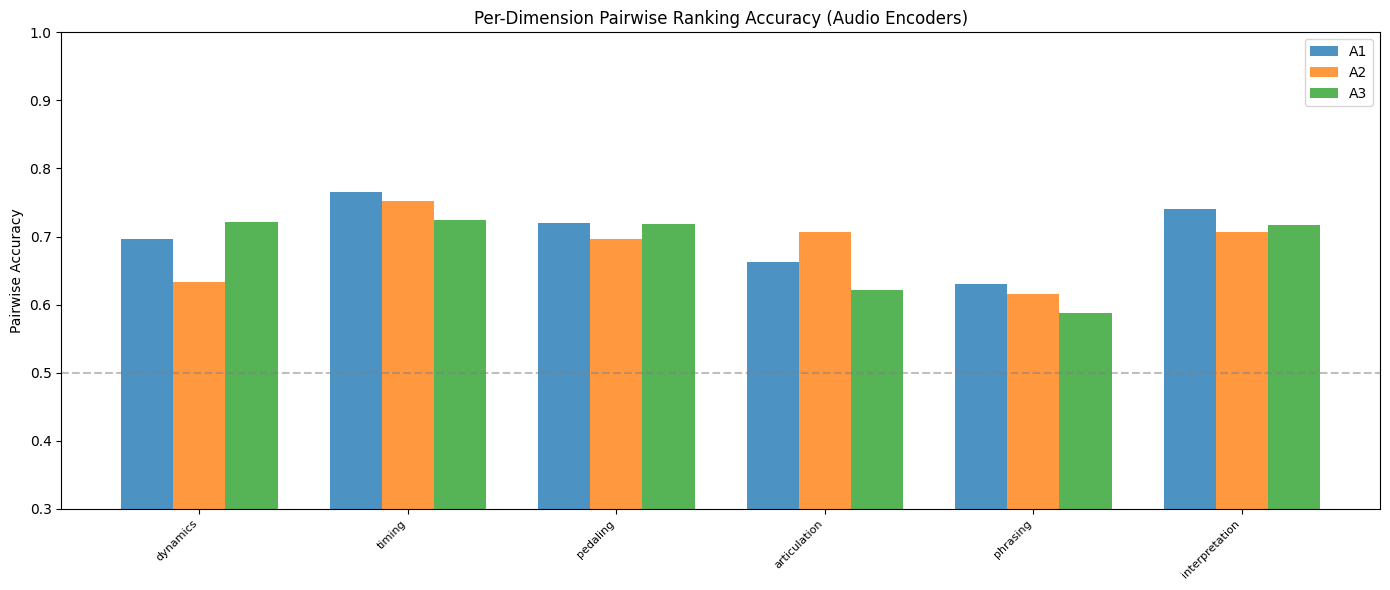

In [17]:
comparison = {}
for name in encoder_models:
    comparison[name] = {}
    if name in all_results:
        comparison[name]['pairwise'] = all_results[name].get('pairwise_mean', 0.0)
        comparison[name]['r2'] = all_results[name].get('r2_mean', 0.0)
    if name in robustness_results:
        comparison[name]['robustness'] = robustness_results[name]['pearson_r']
        comparison[name]['score_drop_pct'] = robustness_results[name]['score_drop_pct']

print(format_comparison_table(comparison))

# Per-dimension bar chart
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
n_dims = NUM_DIMS
x = np.arange(n_dims)
width = 0.25

for i, (name, res) in enumerate(all_results.items()):
    if 'pairwise_detail' not in res:
        continue
    per_dim = res['pairwise_detail']['per_dimension']
    values = [per_dim.get(d, 0.5) for d in range(n_dims)]
    ax.bar(x + i * width, values, width, label=name, alpha=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(DIMENSIONS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Pairwise Accuracy')
ax.set_title('Per-Dimension Pairwise Ranking Accuracy (Audio Encoders)')
ax.legend()
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_ylim(0.3, 1.0)
plt.tight_layout()
plt.show()

## 12. Winner Selection

Selection protocol:
1. **Primary**: Highest pairwise ranking accuracy
2. **Tiebreak**: Highest R-squared on regression
3. **Veto**: Robustness score_drop_pct > 15% disqualifies the model

In [18]:
selection_input = {}
for name, metrics in comparison.items():
    selection_input[name] = {
        'pairwise_mean': metrics.get('pairwise', 0.0),
        'r2_mean': metrics.get('r2', 0.0),
        'score_drop_pct': metrics.get('score_drop_pct', 0.0),
    }

winner = select_winner(selection_input)
print(f'\nWINNER: {winner}')
for name, metrics in comparison.items():
    marker = ' <-- WINNER' if name == winner else ''
    print(f'  {name}: pairwise={metrics.get("pairwise", 0):.4f}, r2={metrics.get("r2", 0):.4f}{marker}')


WINNER: A1
  A1: pairwise=0.7393, r2=0.4032 <-- WINNER
  A2: pairwise=0.7142, r2=0.4206
  A3: pairwise=0.6985, r2=0.2829
